In [1]:
# Program developed by: Chidroop M J
# Registered number: 212225240029

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# XOR input patterns:
x = np.array([[0,0,1,1],
              [0,1,0,1]])
# XOR desired outout:
y = np.array([[0,1,1,0]])

print("Input patterns:\n", x)
print("Desired Output:\n", y)

Input patterns:
 [[0 0 1 1]
 [0 1 0 1]]
Desired Output:
 [[0 1 1 0]]


In [4]:
# Initialization of network architecture:
n_x = 2       # input layer neuron
n_y = 1       # output layer neuron
n_h = 2       # hidden layer neuron

# no. of training samples:
m = x.shape[1]
#learning rate:
lr = 0.1

# init of weights with random values:
np.random.seed(2)

# weights from imput to hidden
w1 = np.random.rand(n_h, n_x)
# weights from hidden to out
w2 = np.random.rand(n_y, n_h)


print("initial weights (input -> hidden):\n", w1)
print("initial weights (hidden -> out):\n", w2)

initial weights (input -> hidden):
 [[0.4359949  0.02592623]
 [0.54966248 0.43532239]]
initial weights (hidden -> out):
 [[0.4203678  0.33033482]]


In [5]:
# defining activation fn & forward propagations :
def sigmoid(z):
  return 1/(1+np.exp(-z))

def forward_prop(w1, w2, x):
  z1 = np.dot(w1, x)
  a1 = sigmoid(z1)
  z2 = np.dot(w2, a1)
  a2 = sigmoid(z2)

  return z1, a1, z2, a2

In [6]:
# defining backpropagation fns:
def back_prop(m, w1, w2, z1, a1, z2, a2, y):
  dz2 = a2 - y
  dw2 = np.dot(dz2, a1.T)/m
  dz1 = np.dot(w2.T, dz2) * a1 * (1-a1)
  dw1 = np.dot(dz1, x.T)/m

  return dz2, dw2, dz1, dw1

In [7]:
# training mlp:
iterations = 10000
losses = []

print("Training initialized !!!\n")

for i in range(iterations):
  # forward prop
  z1, a1, z2, a2 = forward_prop(w1, w2, x)
  loss = -(1 / m) * np.sum(y * np.log(a2) + (1 - y) * np.log(1 - a2))
  losses.append(loss)

  # back prop
  dz2, dw2, dz1, dw1 = back_prop(m, w1, w2, z1, a1, z2, a2, y)

  # weight updation:
  w2 = w2 - lr * dw2
  w1 = w1 - lr * dw1

  if (i + 1) % 1000 == 0:
    print(f"Iteration {i+1}: Loss = {loss:.4f}")

print("\nTraining Completed !!!\n")

Training initialized !!!

Iteration 1000: Loss = 0.6931
Iteration 2000: Loss = 0.6930
Iteration 3000: Loss = 0.6928
Iteration 4000: Loss = 0.6920
Iteration 5000: Loss = 0.6872
Iteration 6000: Loss = 0.6540
Iteration 7000: Loss = 0.5796
Iteration 8000: Loss = 0.5065
Iteration 9000: Loss = 0.4463
Iteration 10000: Loss = 0.3974

Training Completed !!!



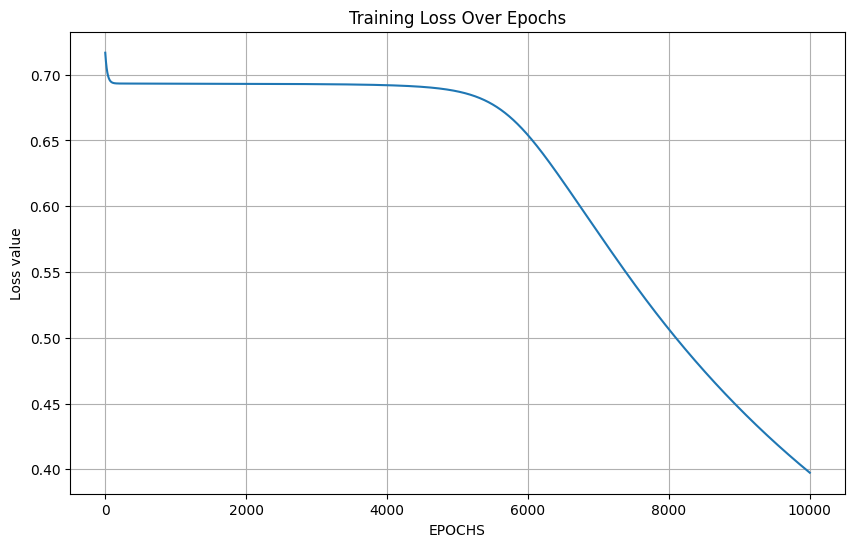

In [8]:
# plotting:
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel("EPOCHS")
plt.ylabel("Loss value")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

In [9]:
# defining pred fn:
def predict(w1, w2, input_data):
  z1, a1, z2, a2 = forward_prop(w1, w2, input_data)
  a2 = np.squeeze(a2)

  if a2 >= 0.5:
      prediction = 1
  else:
      prediction = 0

  return prediction, a2

In [11]:
# testing trained model:
print("=" * 40)
print("XOR Gate Predictions:")
print("=" * 40)
print("Input  Output  Predicted  Probability")
print("-" * 40)

test_cases = [
    np.array([[1], [0]]),
    np.array([[1], [1]]),
    np.array([[0], [1]]),
    np.array([[0], [0]])
]

for test in test_cases:
    pred, prob = predict(w1, w2, test)
    inp = test[:, 0]
    expected = 1 if (inp[0] != inp[1]) else 0  # XOR truth table
    print(f"[{inp[0]}, {inp[1]}]    {expected}      {pred}        {prob:.4f}")

print("=" * 40)


XOR Gate Predictions:
Input  Output  Predicted  Probability
----------------------------------------
[1, 0]    1      1        0.6943
[1, 1]    0      0        0.4253
[0, 1]    1      1        0.6945
[0, 0]    0      0        0.2638


In [12]:
# displaying final weights
print("Final Weights (Input to Hidden):\n", w1)
print("Final Weights (Hidden to Output):\n", w2)

Final Weights (Input to Hidden):
 [[0.6945972  0.69298621]
 [4.95603514 4.90910154]]
Final Weights (Hidden to Output):
 [[-8.76869413  6.71602913]]


In [14]:
# additional testing
all_inputs = np.array([[0, 0, 1, 1],
                       [0, 1, 0, 1]])

for i in range(all_inputs.shape[1]):
    test_input = all_inputs[:, i].reshape(2, 1)
    pred, prob = predict(w1, w2, test_input)
    expected = y[0][i]
    correct = "✓" if pred == expected else "✗"
    print(f"[{test_input[0,0]}, {test_input[1,0]}]     {expected}       {pred}        {correct}")

[0, 0]     0       0        ✓
[0, 1]     1       1        ✓
[1, 0]     1       1        ✓
[1, 1]     0       0        ✓
